In [1]:
import numpy as np
from astropy.coordinates import SkyCoord
from astropy import units as u
import matplotlib.pyplot as plt
from evals import cmds
import pandas as pd
import synthpop as sp
from urllib.request import urlretrieve
import os
import gzip
import shutil
%load_ext autoreload
%autoreload 2
from mulens_rates import misc_utils

/Users/mhuston/anaconda3/lib/python3.11/site-packages/pydantic/_internal/_config.py:341: UserWarning: Valid config keys have changed in V2:
* 'keep_untouched' has been renamed to 'ignored_types'
  warnings.warn(message, UserWarning)


In [2]:
#sp.SynthPop(default_config='huston2025_defaults.synthpop_conf')
# mod = sp.SynthPop('cmd_tests.synthpop_conf', name_for_output='marshall', default_config='huston2025_defaults.synthpop_conf',
#                  extinction_map_kwargs={"name":"maps_from_dustmaps", "dustmap_name":"marshall"})
# mod.init_populations()

mod2 = sp.SynthPop('cmd_tests.synthpop_conf', name_for_output='surot', default_config='huston2025_defaults.synthpop_conf',
                 extinction_map_kwargs={"name":"surot"})
mod2.init_populations()

# mod3 = sp.SynthPop('cmd_tests.synthpop_conf', name_for_output='schlegel', default_config='huston2025_defaults.synthpop_conf',
#                  extinction_map_kwargs={"name":"Galaxia_3D"})
# mod3.init_populations()

 66648 - Execution Date: 10-03-2026 13:17:34


################################ Settings #################################
 66649 - # reading default parameters from
 66649 - default_config_file =  /Users/mhuston/code/synthpop/synthpop/config_files/huston2025_defaults.synthpop_conf 
 66650 - # read configuration from 
 66650 - config_file = '/Users/mhuston/code/synthpop/synthpop/config_files/cmd_tests.synthpop_conf' 


# copy the following to a config file to redo this model generation -------
 66652 - {
    "l_set": [
        0.5
    ],
    "l_set_type": "list",
    "b_set": [
        1.5
    ],
    "b_set_type": "list",
    "random_seed": 274260480,
    "name_for_output": "surot",
    "model_name": "Huston2025",
    "solid_angle": 1e-05,
    "solid_angle_unit": "deg^2",
    "sun": {
        "x": -8.178,
        "y": 0.0,
        "z": 0.017,
        "u": 12.9,
        "v": 245.6,
        "w": 7.78,
        "l_apex_deg": 56.24,
        "b_apex_deg": 22.54
    },
    "lsr": {
        "u

In [3]:
events = cmds.ogle_ews_event_list
lb_flt = cmds.ogle_ews_lb_flt
solid_angle = cmds.ogle_ews_solid_angle

In [4]:
for i,ev in enumerate(events):
    if i==1:
        print(*lb_flt[:,i])
    #mod.process_location(*lb_flt[:,i], solid_angle)
        mod2.process_location(*lb_flt[:,i], solid_angle)
    #mod3.process_location(*lb_flt[:,i], solid_angle)



############################# update location #############################
 414556 - # set location to: 
 414557 - l, b = (0.70 deg, -1.50 deg)
 414557 - # set solid_angle to:
 414558 - solid_angle = 1.111e-03 deg^2


0.701231091255022 -1.4955341356173493




############################# Generate Field ##############################


# Population 0;  bulge ----------------------------------------------------
 423377 - bulge : estimate minimum mass for magnitude limit
 423832 - # From density profile (number density)
 423832 - expected_total_iMass = 412354.5012
 423833 - expected_total_eMass = 225319.1766
 423833 - average_iMass_per_star = 0.5739
 423833 - mass_loss_correction = 0.5464
 423833 - n_expected_stars = 718555.4378
 423834 - without_lm_stars = 166833.1500
 423834 - # Determine velocities when position are generated 
 427457 - # From Generated Field:
 427457 - generated_stars = 166079
 427457 - generated_total_iMass = 296200.4651
 427473 - generated_total_iMass_incl_lowmass = 413862.3049
 427473 - generated_total_eMass = 106634.3323
 427476 - generated_total_eMass_incl_lowmass = 224296.1722
 427476 - det_mass_loss_corr = 0.3600
 427477 - det_mass_loss_corr_incl_lowmass = 0.5419584473010904
 427479 - # Done


# Population 1;  ha

In [7]:
# # Set the information for the OGLE events
# events = cmds.ogle_ews_event_list
# lb_flt = cmds.ogle_ews_lb_flt

# # Gather model data
# model_data_dir = 'outputfiles/ogle_cmds/'
# models = ['Marshall','Surot','Schlegel']
# models_fpref = ['marshall','surot','schlegel']
# model_data = {}
# for i,event in enumerate(events):
#     model_data[event] = {}
#     for j in range(len(models)):
#         model_data[event][models[j]] = pd.read_csv(model_data_dir+models_fpref[j]+'_l'+f'{lb_flt[0][i]:3.3f}'
#                                                    +'_b'+f'{lb_flt[1][i]:3.3f}'+'.csv')[['Bessell_V','Bessell_I','pop']].rename(
#                                                    columns={'Bessell_V':'V','Bessell_I':'I'})
#         #print(event, model_data[event][models[j]])
# cmds.cmds_ogle_ews(model_data)
# plt.savefig('figures/ogle_cmds_altext.pdf')

In [3]:
# Set the information for the OGLE events
events = cmds.ogle_ews_event_list
lb_flt = cmds.ogle_ews_lb_flt

# Gather model data
model_data_dir = 'outputfiles/ogle_cmds/'
models = ['SP-H25']
models_fpref = ['surot']
model_data = {}
for i,event in enumerate(events):
    model_data[event] = {}
    for j in range(len(models)):
        dat0 = pd.read_csv(model_data_dir+models_fpref[j]+'_l'+f'{lb_flt[0][i]:3.3f}'
                                                   +'_b'+f'{lb_flt[1][i]:3.3f}'+'.csv')[['l','b','Bessell_V','Bessell_I','pop']].rename(
                                                   columns={'Bessell_V':'V','Bessell_I':'I'})
        dat0 = dat0[dat0['I']<30].copy()
        dat = misc_utils.calc_blends(dat0, filters=['V','I'], blend_rad=0.65/60**2)
        model_data[event][models[j]] = dat
        #print(event, model_data[event][models[j]])

  0%|          | 0/21249 [00:00<?, ?it/s]

  0%|          | 0/13513 [00:00<?, ?it/s]

  0%|          | 0/5408 [00:00<?, ?it/s]

  0%|          | 0/3325 [00:00<?, ?it/s]

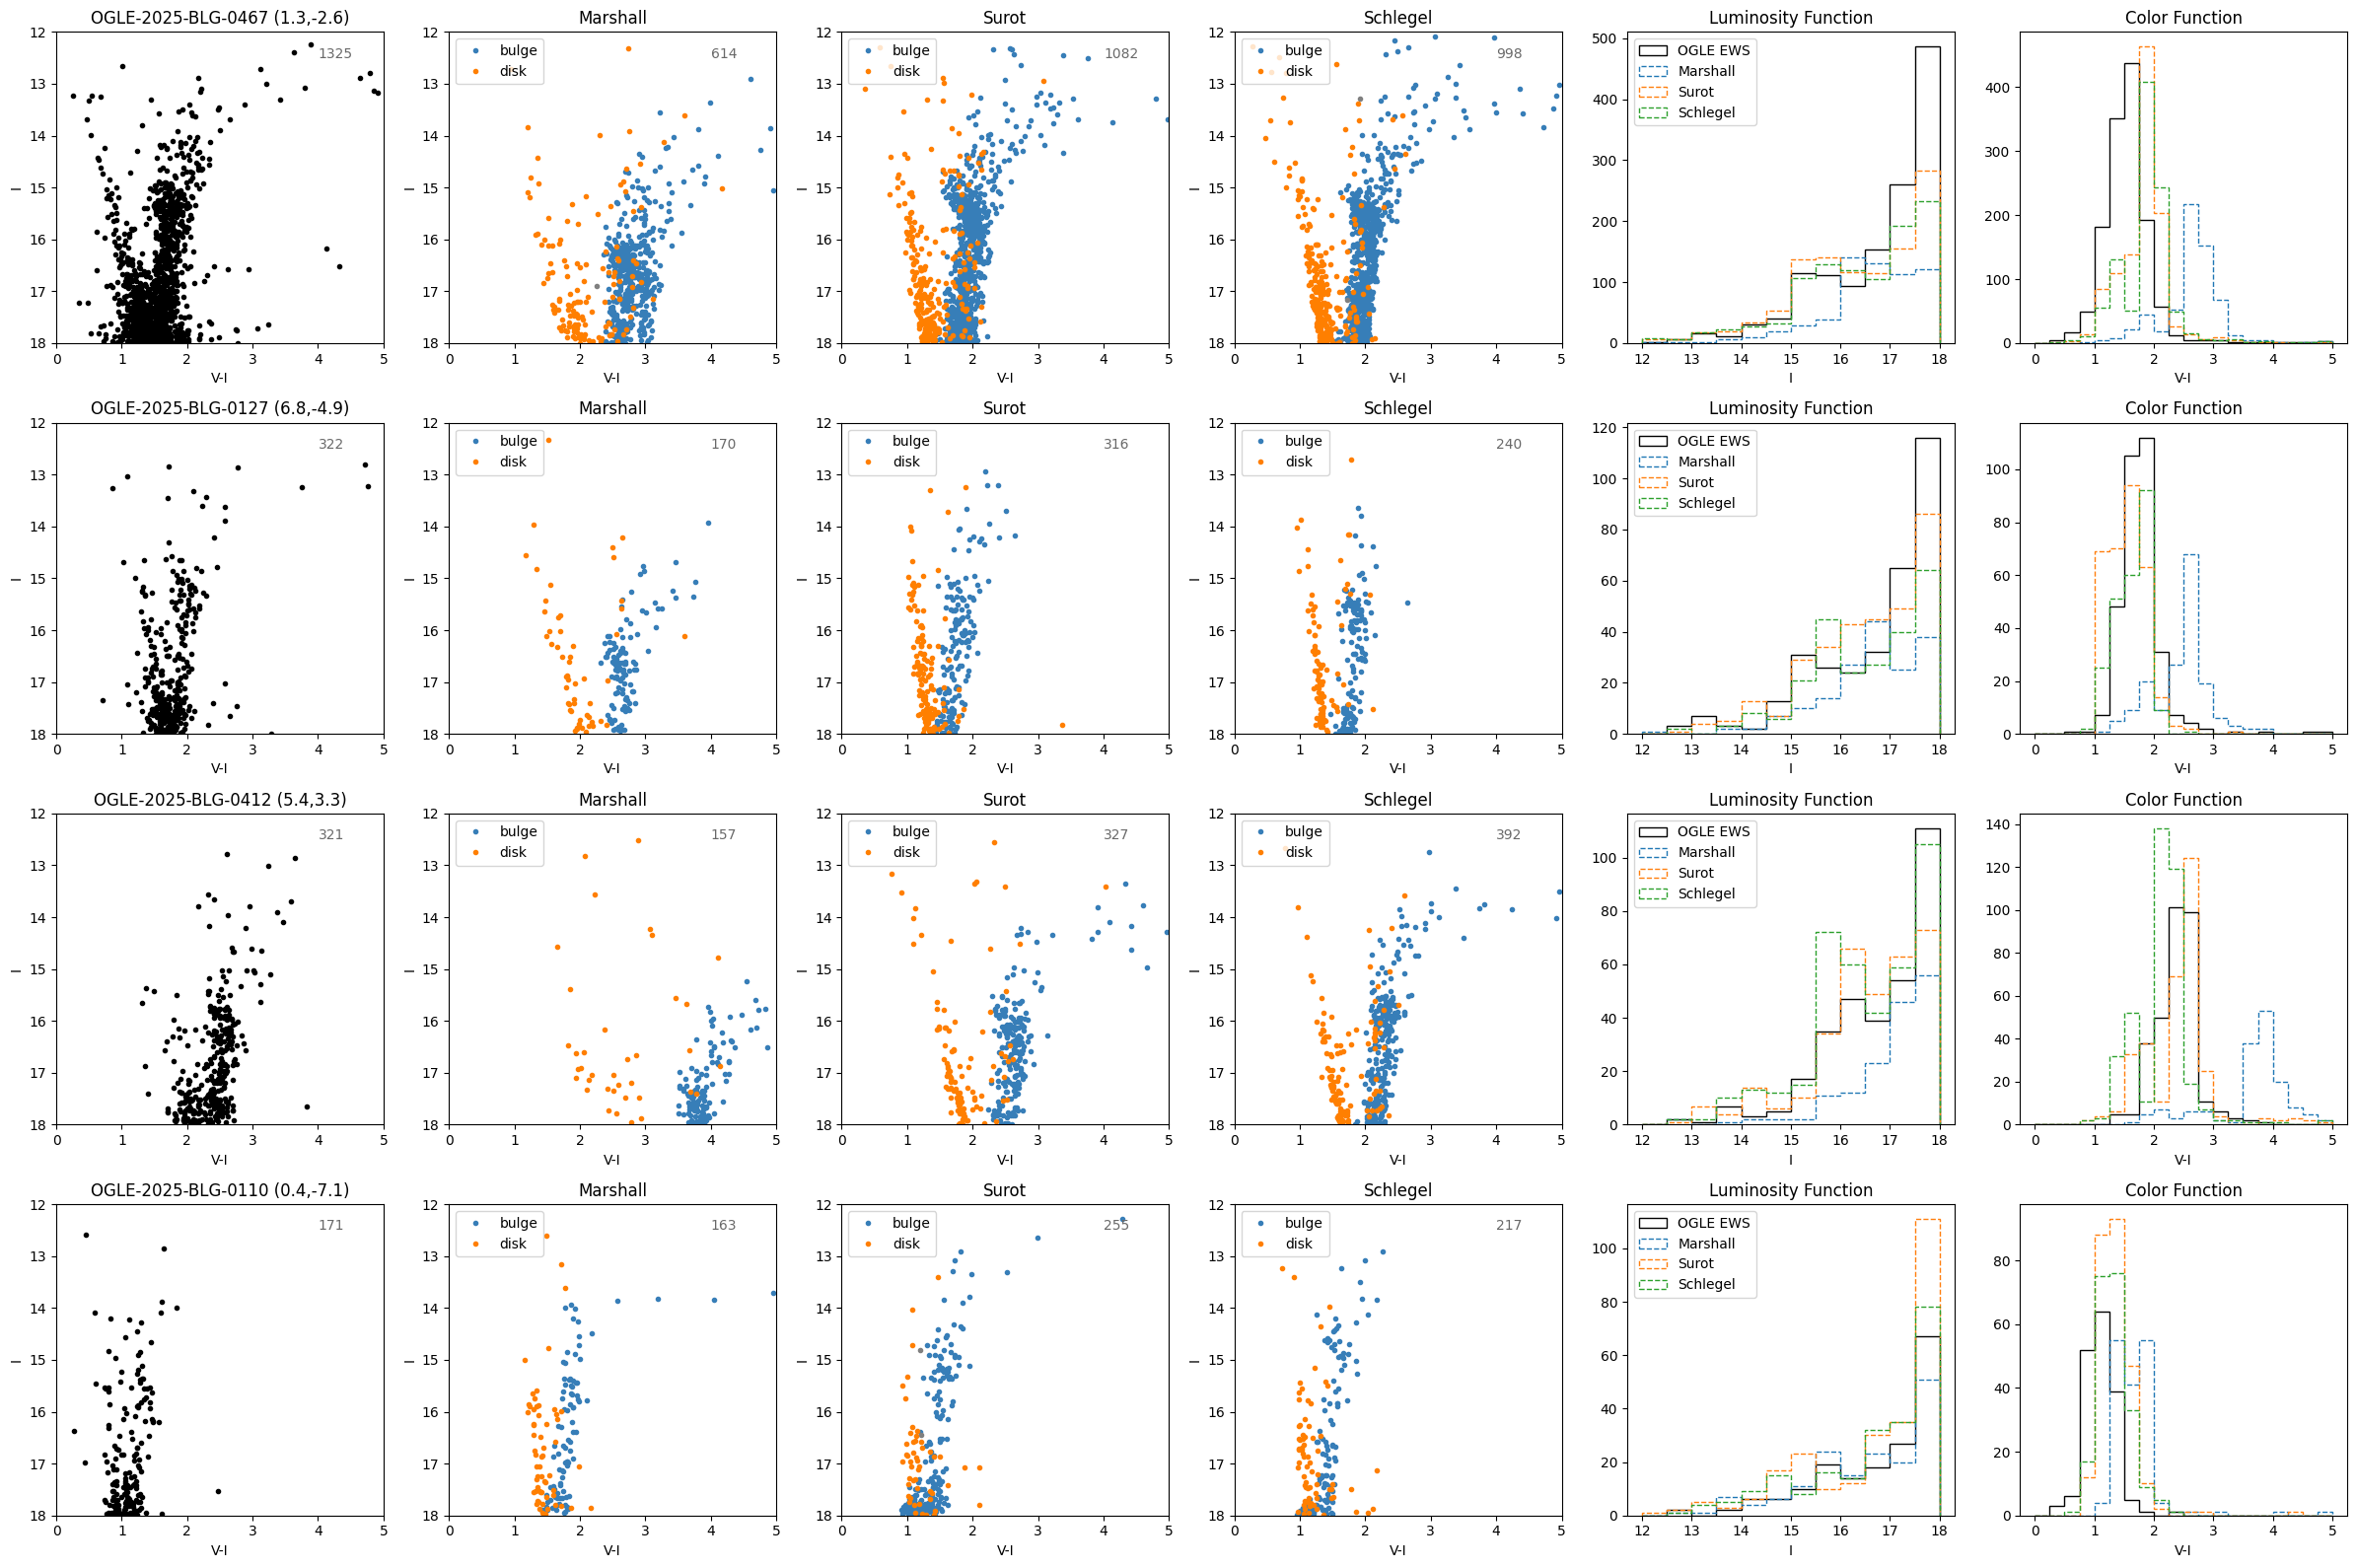

In [18]:
cmds.cmds_ogle_ews(model_data, separate_populations=True)
plt.savefig('figures/ogle_cmds_sep.png')

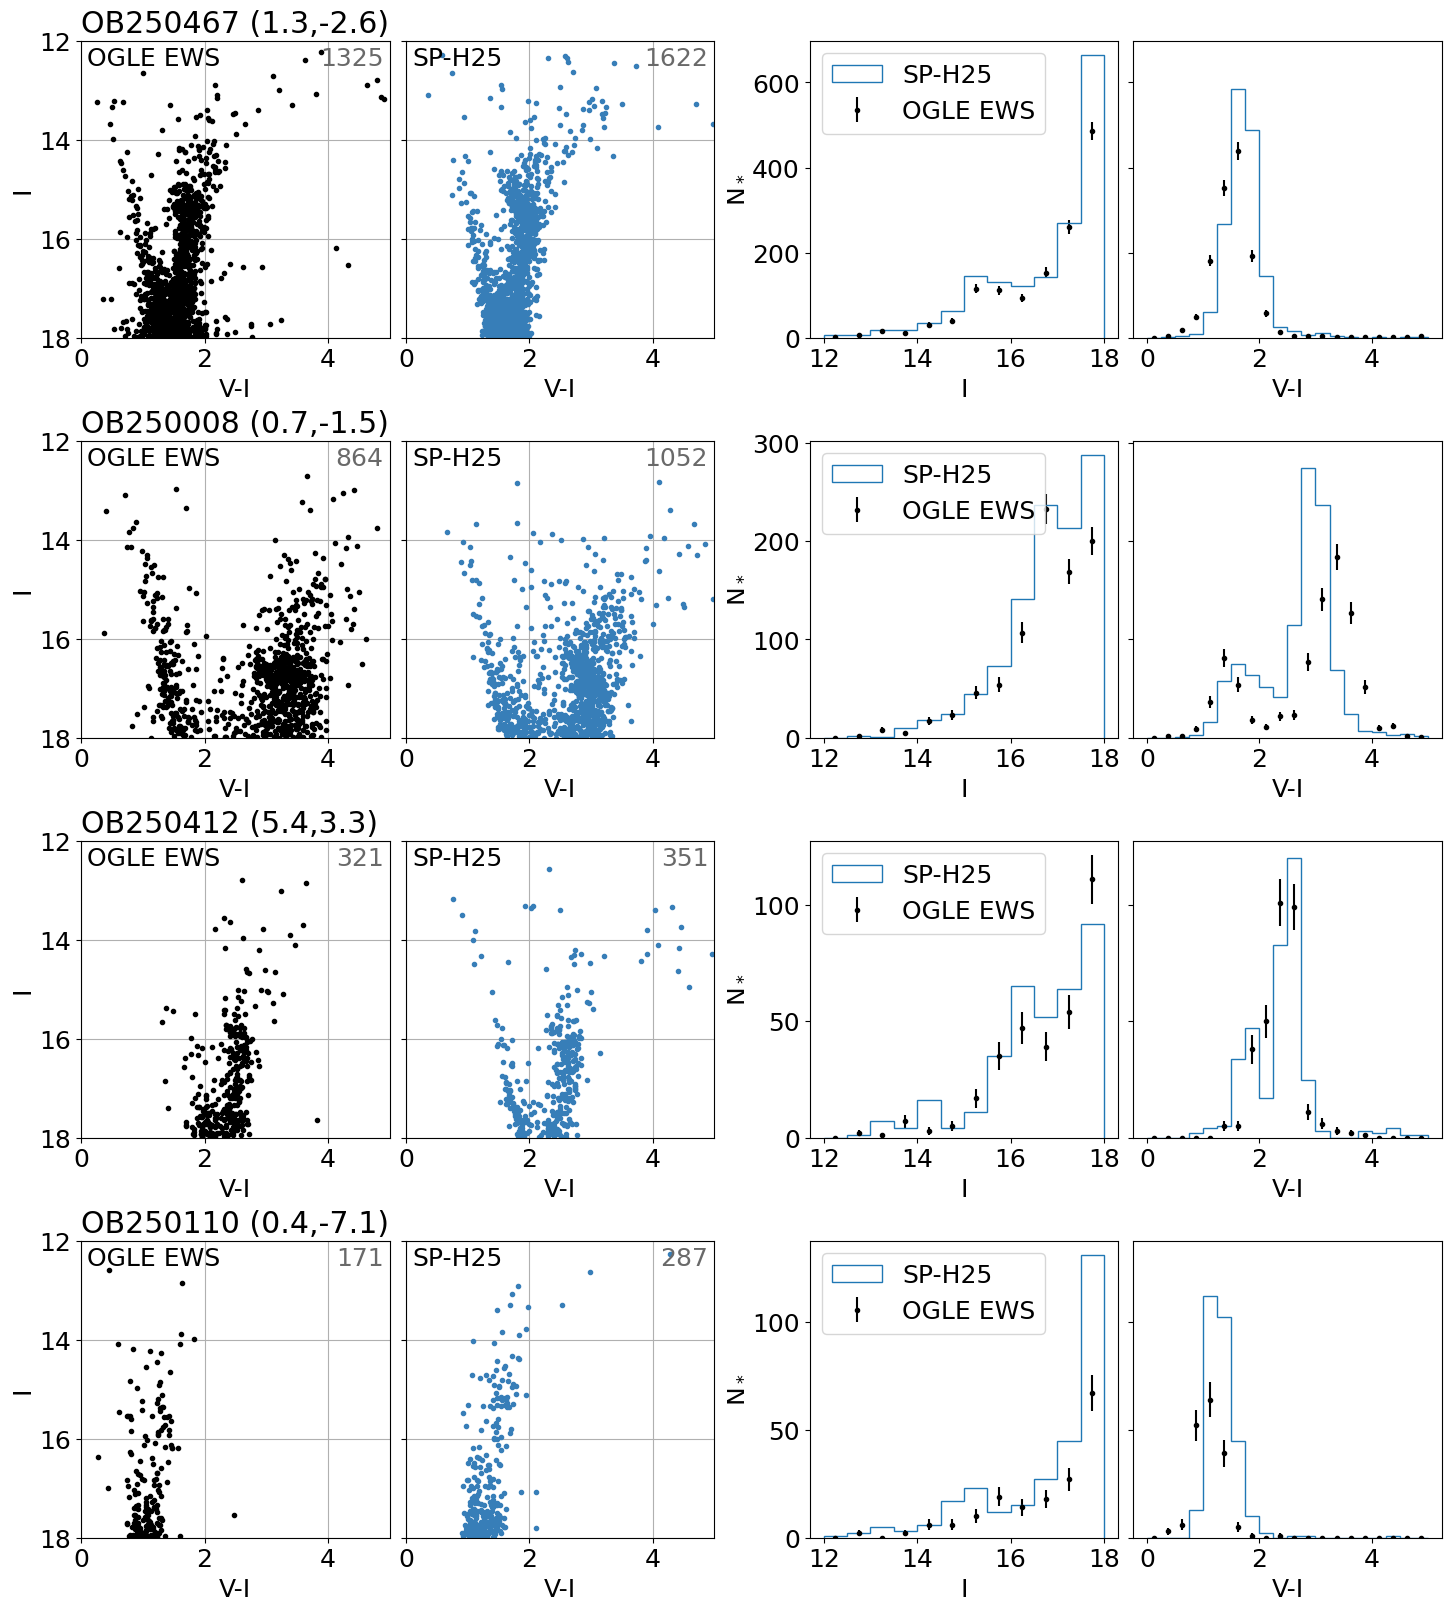

In [5]:
cmds.cmds_ogle_ews(model_data)
plt.savefig('figures/ogle_cmds.pdf')

In [128]:
mod4=0
mod4 = sp.SynthPop('cmd_tests.synthpop_conf', name_for_output='surot2d', default_config='huston2025_defaults.synthpop_conf',
                 extinction_map_kwargs={"name":"surot", "project_3d":False, "dist_2d":2.0})
mod4.init_populations()



################################ Settings #################################
 5225404 - # reading default parameters from
 5225406 - default_config_file =  /Users/mhuston/code/synthpop/synthpop/config_files/huston2025_defaults.synthpop_conf 
 5225407 - # read configuration from 
 5225407 - config_file = '/Users/mhuston/code/synthpop/synthpop/config_files/cmd_tests.synthpop_conf' 


# copy the following to a config file to redo this model generation -------
 5225409 - {
    "l_set": [
        0.5
    ],
    "l_set_type": "list",
    "b_set": [
        1.5
    ],
    "b_set_type": "list",
    "random_seed": 346706619,
    "name_for_output": "surot2d",
    "model_name": "Huston2025",
    "solid_angle": 1e-05,
    "solid_angle_unit": "deg^2",
    "sun": {
        "x": -8.178,
        "y": 0.0,
        "z": 0.017,
        "u": 12.9,
        "v": 245.6,
        "w": 7.78,
        "l_apex_deg": 56.24,
        "b_apex_deg": 22.54
    },
    "lsr": {
        "u_lsr": 1.8,
        "v_lsr": 233.

In [130]:
events = cmds.ogle_ews_event_list
lb_flt = cmds.ogle_ews_lb_flt
solid_angle = cmds.ogle_ews_solid_angle

In [136]:
for i,ev in enumerate(events):
    if i==1:
        print(*lb_flt[:,i])
        mod4.process_location(*lb_flt[:,i], solid_angle)



############################# update location #############################
 5322402 - # set location to: 
 5322403 - l, b = (0.70 deg, -1.50 deg)
 5322403 - # set solid_angle to:
 5322403 - solid_angle = 1.111e-03 deg^2


0.701231091255022 -1.4955341356173493




############################# Generate Field ##############################


# Population 0;  bulge ----------------------------------------------------
 5324146 - bulge : estimate minimum mass for magnitude limit
 5324605 - # From density profile (number density)
 5324606 - expected_total_iMass = 413617.6774
 5324606 - expected_total_eMass = 225331.6763
 5324606 - average_iMass_per_star = 0.5739
 5324607 - mass_loss_correction = 0.5448
 5324607 - n_expected_stars = 720756.6074
 5324607 - without_lm_stars = 167345.3745
 5324607 - # Determine velocities when position are generated 
 5328321 - # From Generated Field:
 5328321 - generated_stars = 166920
 5328321 - generated_total_iMass = 293775.3107
 5328337 - generated_total_iMass_incl_lowmass = 411984.7142
 5328338 - generated_total_eMass = 107161.3582
 5328341 - generated_total_eMass_incl_lowmass = 225370.7617
 5328341 - det_mass_loss_corr = 0.3648
 5328341 - det_mass_loss_corr_incl_lowmass = 0.5470367077975729
 5328343 - # Done


#

In [12]:
d4 = pd.read_csv('outputfiles/ogle_cmds/surot2d_l1.256_b-2.625.csv')[['Bessell_V','Bessell_I','pop']].rename(
                                                   columns={'Bessell_V':'V','Bessell_I':'I'})

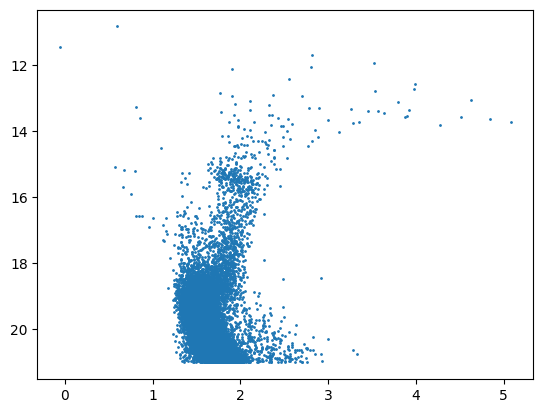

In [19]:
plt.scatter(d4['V']-d4['I'], d4['I'], marker='o', s=1)
plt.gca().invert_yaxis()

In [54]:
sel = pd.read_csv("outputfiles/ogle_cmds/surot_l0.701_b-1.496.csv").rename(columns={'Bessell_V':'Vmag','Bessell_I':'Imag'})

In [60]:
sel.columns

Index(['pop', 'iMass', 'age', 'Fe/H_initial', 'Mass', 'In_Final_Phase', 'Dist',
       'l', 'b', 'vr_bc', 'mul', 'mub', 'x', 'y', 'z', 'U', 'V', 'W', 'VR_LSR',
       'A_Ks', 'log_L', 'log_Teff', 'log_g', '[Fe/H]', 'log_R', 'phase',
       'Bessell_U', 'Bessell_B', 'Vmag', 'Bessell_R', 'Imag', 'VISTA_J',
       'VISTA_H', 'VISTA_Ks'],
      dtype='object')

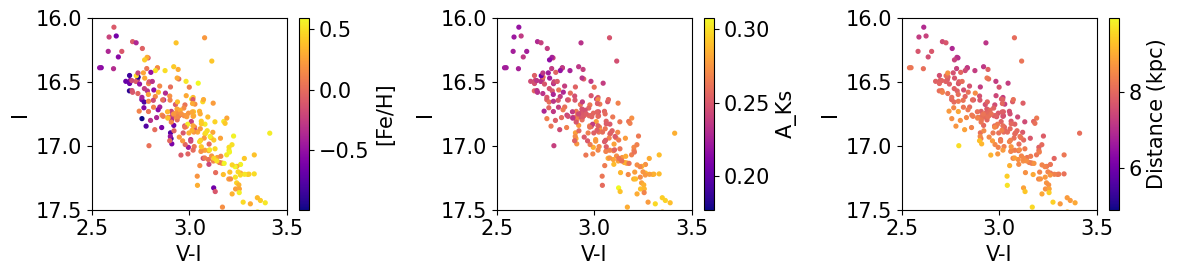

In [126]:
plt.rcParams["font.size"] = 15

sel = pd.read_csv("outputfiles/ogle_cmds/surot_l0.701_b-1.496.csv").rename(columns={'Bessell_V':'Vmag','Bessell_I':'Imag'})
sel = sel[(sel['pop']==0.0) & (np.abs(sel['phase']-3)<0.5)]

fig,ax = plt.subplots(nrows=1,ncols=3, figsize=(12,3))
s=30
im0 = ax[0].scatter(sel['Vmag']-sel['Imag'], sel['Imag'],marker= '.',s=s, c=sel['[Fe/H]'],
                    cmap='plasma') #, vmin=-1,vmax=0.5)
fig.colorbar(im0, label='[Fe/H]')
im1 = ax[1].scatter(sel['Vmag']-sel['Imag'], sel['Imag'],marker= '.',s=s, c=sel['A_Ks'],
                    cmap='plasma') #, vmin=0.2,vmax=0.33)
fig.colorbar(im1, label='A_Ks')
im2 = ax[2].scatter(sel['Vmag']-sel['Imag'], sel['Imag'],marker= '.',s=s, c=sel['Dist'],
                    cmap='plasma') #, vmin=6,vmax=10)
fig.colorbar(im2, label='Distance (kpc)')

for axi in ax:
    axi.set_ylim(17.5,16)
    axi.set_xlim(2.5,3.5)
    axi.set_xlabel('V-I')
    axi.set_ylabel('I')
fig.tight_layout()
fig.savefig('figures/rc_elongation.png')

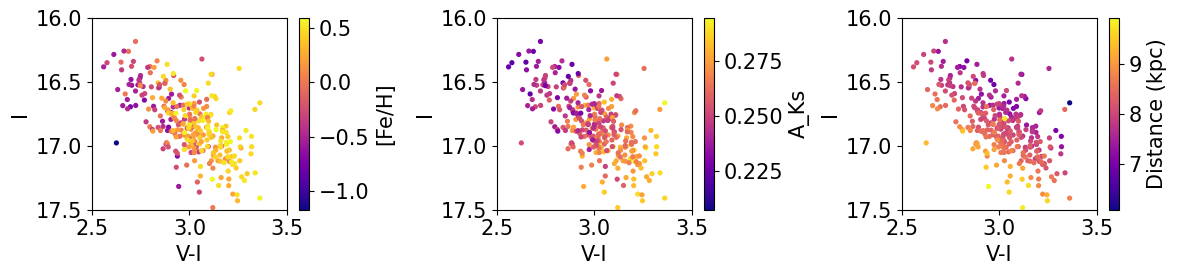

In [137]:
plt.rcParams["font.size"] = 15

sel = pd.read_csv("outputfiles/ogle_cmds/surot2d_l0.701_b-1.496.csv").rename(columns={'Bessell_V':'Vmag','Bessell_I':'Imag'})
sel = sel[(sel['pop']==0.0) & (np.abs(sel['phase']-3)<0.5)]

fig,ax = plt.subplots(nrows=1,ncols=3, figsize=(12,3))
s=30
im0 = ax[0].scatter(sel['Vmag']-sel['Imag'], sel['Imag'],marker= '.',s=s, c=sel['[Fe/H]'],
                    cmap='plasma') #, vmin=-1,vmax=0.5)
fig.colorbar(im0, label='[Fe/H]')
im1 = ax[1].scatter(sel['Vmag']-sel['Imag'], sel['Imag'],marker= '.',s=s, c=sel['A_Ks'],
                    cmap='plasma') #, vmin=0.2,vmax=0.33)
fig.colorbar(im1, label='A_Ks')
im2 = ax[2].scatter(sel['Vmag']-sel['Imag'], sel['Imag'],marker= '.',s=s, c=sel['Dist'],
                    cmap='plasma') #, vmin=6,vmax=10)
fig.colorbar(im2, label='Distance (kpc)')

for axi in ax:
    axi.set_ylim(17.5,16)
    axi.set_xlim(2.5,3.5)
    axi.set_xlabel('V-I')
    axi.set_ylabel('I')
fig.tight_layout()
fig.savefig('figures/rc_elongation_ext2d.png')

In [100]:
sel.columns

Index(['pop', 'iMass', 'age', 'Fe/H_initial', 'Mass', 'In_Final_Phase', 'Dist',
       'l', 'b', 'vr_bc', 'mul', 'mub', 'x', 'y', 'z', 'U', 'V', 'W', 'VR_LSR',
       'A_Ks', 'logL', 'logTeff', 'logg', 'Fe/H_evolved', 'log_radius',
       'phase', 'Bessell_U', 'Bessell_B', 'Vmag', 'Bessell_R', 'Imag',
       'VISTA_J', 'VISTA_H', 'VISTA_Ks', 'Dim_Compact_Object_Flag'],
      dtype='object')

In [171]:
import fetch_data

In [174]:
ogle_ews_event_list = ['OGLE-2025-BLG-0467','OGLE-2025-BLG-0008', 'OGLE-2025-BLG-0412', 'OGLE-2025-BLG-0110'] #'OGLE-2025-BLG-0127', 
ogle_ews_cats = fetch_data.ogle_ews_mapdat(ogle_ews_event_list)

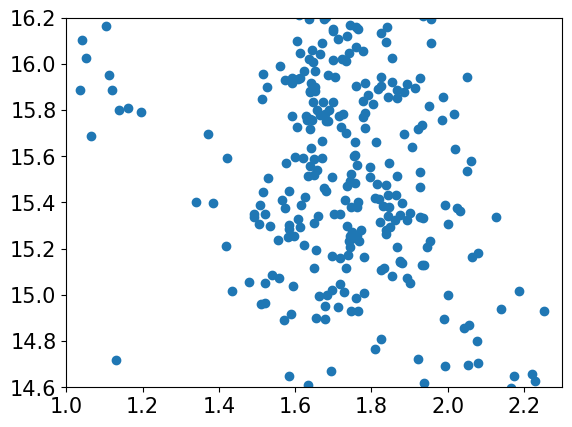

In [181]:
dat = ogle_ews_cats['OGLE-2025-BLG-0467']
plt.scatter(dat['V']-dat['I'], dat['I'])
plt.ylim(16.2,14.6)
plt.xlim(1.0,2.3)
plt.gca().invert_yaxis()

-1.2280488 0.48184222
0.086052604 0.1548659
5.1867625 10.97911


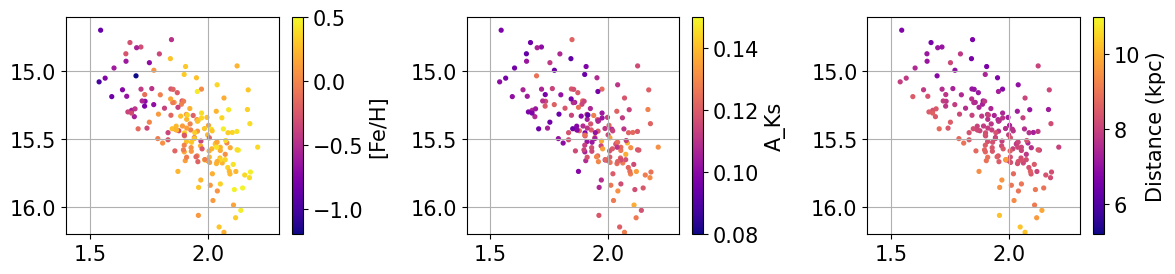

In [165]:
sel = pd.read_csv("outputfiles/ogle_cmds/surot_l1.256_b-2.625.csv").rename(columns={'Bessell_V':'Vmag','Bessell_I':'Imag'})
sel = sel[(sel['pop']==0.0) & (np.abs(sel['phase']-3)<0.5)]
print(np.min(sel['Fe/H_initial']), np.max(sel['Fe/H_initial']))
print(np.min(sel['A_Ks']), np.max(sel['A_Ks']))
print(np.min(sel['Dist']), np.max(sel['Dist']))

fig,ax = plt.subplots(nrows=1,ncols=3, figsize=(12,3))
s=30
im0 = ax[0].scatter(sel['Vmag']-sel['Imag'], sel['Imag'],marker= '.',s=s, c=sel['Fe/H_initial'],
                    cmap='plasma', vmin=-1.2,vmax=0.5)
fig.colorbar(im0, label='[Fe/H]')
im1 = ax[1].scatter(sel['Vmag']-sel['Imag'], sel['Imag'],marker= '.',s=s, c=sel['A_Ks'],
                    cmap='plasma', vmin=0.08,vmax=0.15)
fig.colorbar(im1, label='A_Ks')
im2 = ax[2].scatter(sel['Vmag']-sel['Imag'], sel['Imag'],marker= '.',s=s, c=sel['Dist'],
                    cmap='plasma', vmin=5.2,vmax=11)
fig.colorbar(im2, label='Distance (kpc)')

for axi in ax:
    axi.set_ylim(16.2,14.6)
    axi.set_xlim(1.4,2.3)
    axi.grid(True)
fig.tight_layout()

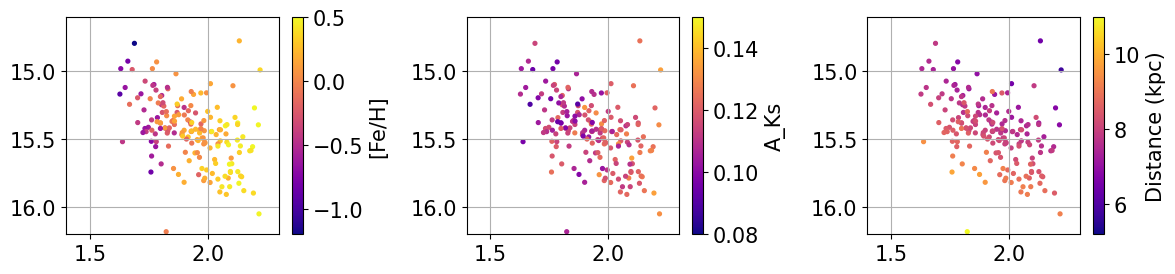

In [166]:
sel = pd.read_csv("outputfiles/ogle_cmds/surot2d_l1.256_b-2.625.csv").rename(columns={'Bessell_V':'Vmag','Bessell_I':'Imag'})
sel = sel[(sel['pop']==0.0) & (np.abs(sel['phase']-3)<0.5)]

fig,ax = plt.subplots(nrows=1,ncols=3, figsize=(12,3))
s=30
im0 = ax[0].scatter(sel['Vmag']-sel['Imag'], sel['Imag'],marker= '.',s=s, c=sel['Fe/H_initial'],
                    cmap='plasma', vmin=-1.2,vmax=0.5)
fig.colorbar(im0, label='[Fe/H]')
im1 = ax[1].scatter(sel['Vmag']-sel['Imag'], sel['Imag'],marker= '.',s=s, c=sel['A_Ks'],
                    cmap='plasma', vmin=0.08,vmax=0.15)
fig.colorbar(im1, label='A_Ks')
im2 = ax[2].scatter(sel['Vmag']-sel['Imag'], sel['Imag'],marker= '.',s=s, c=sel['Dist'],
                    cmap='plasma', vmin=5.2,vmax=11)
fig.colorbar(im2, label='Distance (kpc)')

for axi in ax:
    axi.set_ylim(16.2,14.6)
    axi.set_xlim(1.4,2.3)
    axi.grid(True)
fig.tight_layout()